# Backward in Time, Central in Space (BTCS) method
The BTCS method is an **implicit finite difference method** where the new state depends implicitly on three points at the same new time step. It is based on **backward Euler in time** and **central difference in space**, giving **first-order convergence in time** and **second-order convergence in space**. Unlike FTCS, BTCS is **unconditionally stable**.

# Heat equation: 1D metal heated in the middle
$$
\frac{\partial T}{\partial t} = c^2 \frac{\partial^2 T}{\partial x^2}, 
\quad T_t = c^2 T_{xx},
$$
$\Rightarrow$ *time evolution = constant × curvature of the function (parabolic term)*.

## Discretization
We choose **j** as the index of the *time axis* and **i** as the index of the *space axis*. 

**Backward Difference in time:**
$$
T_t \approx \frac{T_{i,j} - T_{i,j-1}}{\Delta t} + \mathcal{O}(\Delta t),
$$
**Central Difference in space:**
$$
T_{xx} \approx \frac{T_{i+1,j} - 2 T_{i,j} + T_{i-1,j}}{\Delta x^2} + \mathcal{O}(\Delta x^2),
$$
where the spatial derivative is evaluated at the **new state** $j$.

Then,
$$
\Rightarrow \frac{T_{i,j} - T_{i,j-1}}{\Delta t} = c^2 \frac{T_{i+1,j} - 2 T_{i,j} + T_{i-1,j}}{\Delta x^2},
$$
$$
T_{i,j} - T_{i,j-1} = r \, (T_{i+1,j} - 2 T_{i,j} + T_{i-1,j}),
$$
$$
-r T_{i-1,j} + (1+2r) T_{i,j} - r T_{i+1,j} = T_{i,j-1},
$$
where
$$
r = \frac{c^2 \Delta t}{\Delta x^2}.
$$

Unlike FTCS, we need to solve a **linear system of equations** for $T_{i,j}$ at each time step.

- We get an upside-down triangle on the grid, the stencil.
- Since we're missing steps, we sweep the triangle along space so we have a closed trajectory. Then, we have a system of equations we have to solve.
- We have the same number of equations and unknowns for each time step.
  
---

## Matrix form
For \(N\) interior spatial points, we can write the system as:

$$
\mathbf{A} \mathbf{T}^j = \mathbf{T}^{j-1},
$$

where $\mathbf{T}^j = [T_{1,j}, T_{2,j}, \dots, T_{N,j}]^T$ and $\mathbf{A}$ is a tridiagonal matrix:

$$
\mathbf{A} =
\begin{bmatrix}
1+2r & -r & 0 & \dots & 0 \\
-r & 1+2r & -r & \dots & 0 \\
0 & -r & 1+2r & \dots & 0 \\
\vdots & & & \ddots & \vdots \\
0 & \dots & 0 & -r & 1+2r
\end{bmatrix}.
$$

---

## Von-Neumann Stability Analysis
We assume a Fourier-mode perturbation:

$$
T_{i,j} = A^j e^{\mathbf{i} k x_i}.
$$

Substitute into the BTCS scheme:

$$
-r T_{i-1,j} + (1+2r) T_{i,j} - r T_{i+1,j} = T_{i,j-1},
$$
$$
-r A^j e^{i k x_{i-1}} + (1+2r) A^j e^{i k x_i} - r A^j e^{i k x_{i+1}} = A^{j-1} e^{i k x_i},
$$
$$
A^j \left[ -r e^{-i k \Delta x} + (1+2r) - r e^{i k \Delta x} \right] e^{i k x_i} = A^{j-1} e^{i k x_i},
$$
$$
A = \frac{1}{1 + 2 r - 2 r \cos (k \Delta x)}.
$$

### Stable methods:
The amplitude of the perturbation should decrease for the method to be stable.
$$
\frac{|A^{j}|}{|A^{j-1}|} \le 1, \forall k.
$$
$$
\Rightarrow 1 \le |1 + 2 r - 2 r \cos (k \Delta x)|,
$$
$$
0 < 2r(1 - \cos (k \Delta x)).
$$
Since $\cos(k \Delta x) \in [-1, 1]$, the most restrictive condition occurs at the minimum value of $\cos(k \Delta x) = -1$. Thus, the BTCS scheme is **unconditionally stable**. There is really no restriction on $r$.

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Domain definition:

In [2]:
# Steps:
h = 0.025 # Step size -> delta_x
k = 0.1 # Time step -> delta_t

# Axes:
x = np.arange(0, 1 + h, h)
t = np.arange(0, 1 + k, k)

In [3]:
# Fix c^2
c_2 = 1.

# Fix r
r_factor = c_2*k/h**2

print(r_factor)

159.99999999999997


### 2. Set up the ICs/BCs:

In [4]:
# initial and boundary conditions
ics = np.sin(np.pi*x)

bcs = [0, 0] # T=0 at x=0, and x=a=1.0

### 3. Create the solution array for $T(x,t)$


In [5]:
# Matrix
n = len(x)
m = len(t)

#print(n,m)

# Fill up the T matrix with zeroes
T = np.zeros((n, m))

#print(T)

### 4. Fill up the matrix elements with the ICs/BCs:

In [6]:
# Add the initial conditions
T[:, 0] = ics # We are adding a np.sin(np.pi*x)

# Add the boundary conditions
T[0, :] = bcs[0]
T[-1, :] = bcs[1]

#print(T.T)

### 5. Fill up the inner elements of the matrix using our implicit formula:

$$(1+2r)\,T_{i,j} -r\,T_{i+1, j} - r\,T_{i-1, j} = T_{i, j-1}$$

In [7]:
# Fill up the diagonal values of the matrix

D_matrix_0 = np.diag([1 + 2*r_factor]*(n - 2), 0)

print(D_matrix_0)

[[321.   0.   0. ...   0.   0.   0.]
 [  0. 321.   0. ...   0.   0.   0.]
 [  0.   0. 321. ...   0.   0.   0.]
 ...
 [  0.   0.   0. ... 321.   0.   0.]
 [  0.   0.   0. ...   0. 321.   0.]
 [  0.   0.   0. ...   0.   0. 321.]]


In [8]:
D_matrix_n = np.diag([-r_factor]*(n - 3), -1)

print(D_matrix_n)

[[   0.    0.    0. ...    0.    0.    0.]
 [-160.    0.    0. ...    0.    0.    0.]
 [   0. -160.    0. ...    0.    0.    0.]
 ...
 [   0.    0.    0. ...    0.    0.    0.]
 [   0.    0.    0. ... -160.    0.    0.]
 [   0.    0.    0. ...    0. -160.    0.]]


In [9]:
D_matrix_p = np.diag([-r_factor]*(n - 3), +1)

print(D_matrix_p)

[[   0. -160.    0. ...    0.    0.    0.]
 [   0.    0. -160. ...    0.    0.    0.]
 [   0.    0.    0. ...    0.    0.    0.]
 ...
 [   0.    0.    0. ...    0. -160.    0.]
 [   0.    0.    0. ...    0.    0. -160.]
 [   0.    0.    0. ...    0.    0.    0.]]


In [10]:
# Matrix algebra to get the necessary Diag matrix

D_matrix = D_matrix_0 + D_matrix_n + D_matrix_p

print(D_matrix)

print(D_matrix.shape, D_matrix_n.shape, D_matrix_p.shape)

[[ 321. -160.    0. ...    0.    0.    0.]
 [-160.  321. -160. ...    0.    0.    0.]
 [   0. -160.  321. ...    0.    0.    0.]
 ...
 [   0.    0.    0. ...  321. -160.    0.]
 [   0.    0.    0. ... -160.  321. -160.]
 [   0.    0.    0. ...    0. -160.  321.]]
(39, 39) (39, 39) (39, 39)


### 6. Solve the linear system of eqs:

In [11]:
# Loop over the time axis:

# Iteration over each time step, each row on the matrix
for j in range(1, m):
    
    # Create b vector using the (j-1) line, make a safe copy
    b = T[1:-1, j-1].copy() # A new b is created for each iteration, as we fill up the matrix
    
    # Add the BCs
    # Left BC
    b[0]  = b[0] + r_factor*T[0, j]
    
    # Right BC
    b[-1] = b[-1] + r_factor*T[-1, j]
    
    #print(b)
    #print(b.shape)
    
    # The solution for j
    sln_unknown = np.linalg.solve(D_matrix, b)
    
    print(sln_unknown)
    
    T[1:-1, j] = sln_unknown
    
    #print(solution)

print(T)

[0.03949708 0.07875064 0.11751868 0.15556218 0.19264659 0.22854326
 0.2630309  0.29589685 0.32693851 0.35596448 0.38279581 0.40726708
 0.42922741 0.44854141 0.46509001 0.47877117 0.48950054 0.49721198
 0.50185795 0.50340979 0.50185795 0.49721198 0.48950054 0.47877117
 0.46509001 0.44854141 0.42922741 0.40726708 0.38279581 0.35596448
 0.32693851 0.29589685 0.2630309  0.22854326 0.19264659 0.15556218
 0.11751868 0.07875064 0.03949708]
[0.01988322 0.03964384 0.05916006 0.07831153 0.09698018 0.11505092
 0.13241233 0.14895737 0.16458405 0.17919601 0.19270316 0.20502224
 0.21607728 0.22580014 0.23413086 0.24101809 0.24641937 0.25030138
 0.25264021 0.25342142 0.25264021 0.25030138 0.24641937 0.24101809
 0.23413086 0.22580014 0.21607728 0.20502224 0.19270316 0.17919601
 0.16458405 0.14895737 0.13241233 0.11505092 0.09698018 0.07831153
 0.05916006 0.03964384 0.01988322]
[0.01000941 0.0199571  0.02978175 0.03942279 0.04882077 0.05791776
 0.06665766 0.0749866  0.08285322 0.09020902 0.09700866 0.1

### 7. Plotting the solutions for  $T(x,t)$
A. Temperature vs. Positon space:

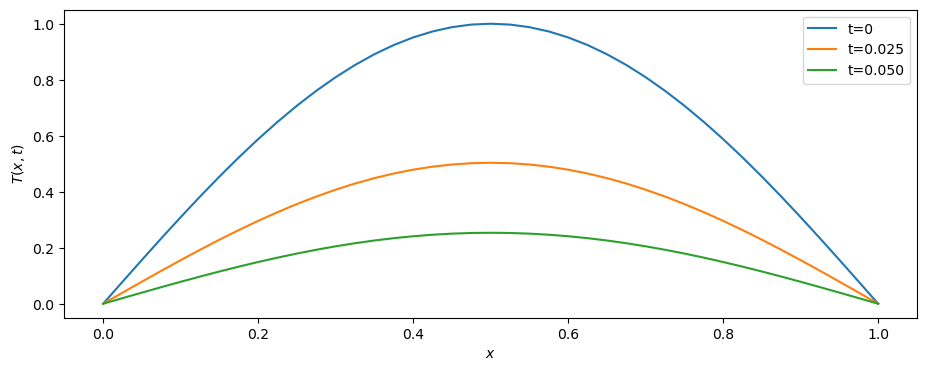

In [12]:
# Figure environment:

plt.figure(figsize=(11,4))

plt.plot(x, T[:, 0], label = 't=0')

plt.plot(x, T[:, 1], label = 't=0.025')

plt.plot(x, T[:, 2], label = 't=0.050')

plt.legend()

plt.xlabel(r"$x$")
plt.ylabel(r"$T(x,t)$")

plt.show()

### In one go:

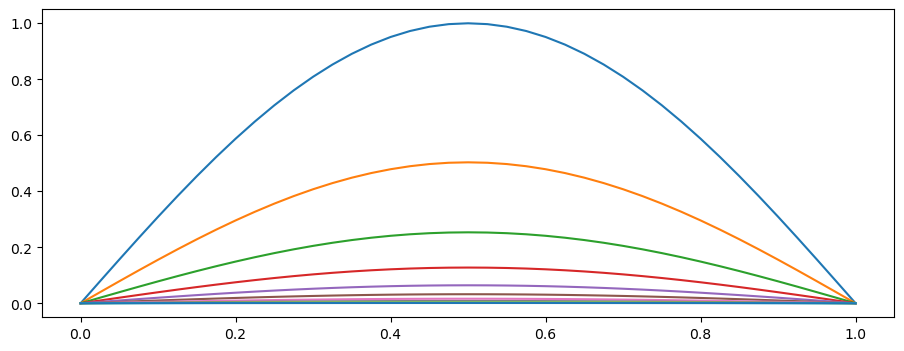

In [13]:
plt.figure(figsize=(11,4))

plt.plot(x, T)

#plt.legend()
plt.show()

#### B. Temperature surface projection:

In [14]:
# Create 2D meshgrid

x_grid, t_grid = np.meshgrid(x, t)

print(x_grid.shape, t_grid.shape, T.T.shape)

(11, 41) (11, 41) (11, 41)


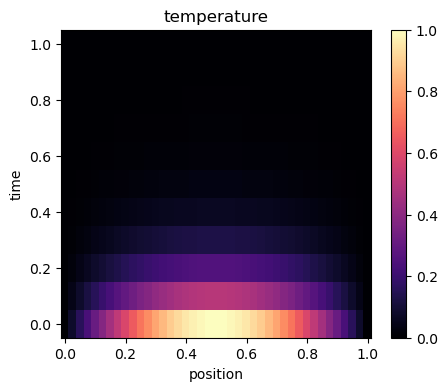

In [15]:
plt.figure(figsize=(5,4))

z_temp = plt.pcolor(x_grid, t_grid, T.T, cmap = 'magma')

plt.xlabel("position")

plt.ylabel("time")

plt.title("temperature")

plt.colorbar(z_temp)

plt.show()

/tmp/ipykernel_11264/3014180666.py:12: UserWarning: Adding colorbar to a different Figure <Figure size 500x400 with 2 Axes> than <Figure size 500x400 with 2 Axes> which fig.colorbar is called on.
  plt.colorbar(z_temp, ax=ax)


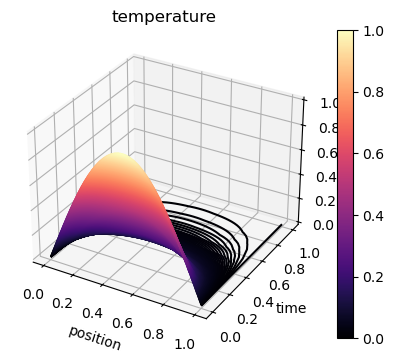

In [16]:
plt.figure(figsize=(5,4))

ax  = plt.axes(projection='3d')

ax.contour3D(x_grid, t_grid, T.T, 500, cmap = 'magma')

plt.xlabel("position")
plt.ylabel("time")

plt.title("temperature")

plt.colorbar(z_temp, ax=ax)

plt.show()